<a href="https://colab.research.google.com/github/selcannatakk/selcanatakai-code/blob/main/on_custom_dataset_for_idcards_and_person_yolov12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls

drive  sample_data


In [3]:
!git clone https://github.com/sunsmarterjie/yolov12.git
%cd yolov12

Cloning into 'yolov12'...
remote: Enumerating objects: 1173, done.
remote: Counting objects: 100% (402/402), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 1173 (delta 335), reused 323 (delta 323), pack-reused 771 (from 1)
Receiving objects: 100% (1173/1173), 1.90 MiB | 4.84 MiB/s, done.
Resolving deltas: 100% (545/545), done.
/content/yolov12


In [4]:
!wget https://github.com/Dao-AILab/flash-attention/releases/download/v2.7.3/flash_attn-2.7.3+cu11torch2.2cxx11abiFALSE-cp311-cp311-linux_x86_64.whl


--2026-08-10 12:35:36--  https://github.com/Dao-AILab/flash-attention/releases/download/v2.7.3/flash_attn-2.7.3+cu11torch2.2cxx11abiFALSE-cp311-cp311-linux_x86_64.whl
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/494232964/b7fb7022-424c-4ac2-b46b-a41f386edaa5?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-08-10T13%3A24%3A01Z&rscd=attachment%3B+filename%3Dflash_attn-2.7.3%2Bcu11torch2.2cxx11abiFALSE-cp311-cp311-linux_x86_64.whl&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-08-10T12%3A23%3A45Z&ske=2026-08-10T13%3A24%3A01Z&sks=b&skv=2018-11-09&sig=yN%2BkyroxanG0v4DYGRU3xuNSqJB1Z1JnqrDUvF8RKnI%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNv

In [5]:
!pip install -r requirements.txt
!pip install -e .

ERROR: flash_attn-2.7.3+cu11torch2.2cxx11abiFALSE-cp311-cp311-linux_x86_64.whl is not a supported wheel on this platform.
Obtaining file:///content/yolov12
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ultralytics (pyproject.toml) ... done
  Created wheel for ultralytics: filename=ultralytics-8.3.63-0.editable-py3-none-any.whl size=20185 sha256=174a4149fb32a581ead60e319312ee44a458732e86b01d2611b80dd8f3096fad
  Stored in directory: /tmp/pip-ephem-wheel-cache-5ga0eiba/wheels/1c/fb/0a/30d0595ef49b9e09568179373ed2bf43f5f378a2cae77d50b4
Successfully built ultralytics


In [6]:
!cat /content/drive/MyDrive/data/datasets/id_cards_dataset/id_cards.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['ID card', 'person']


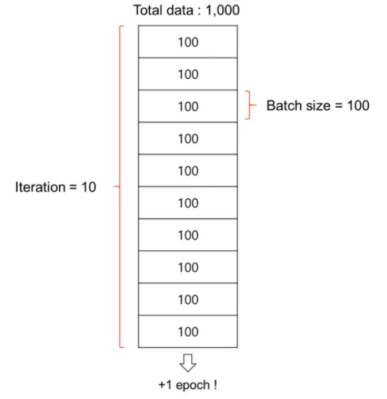

-> Veri artırma (augmentation) teknikleri: mosaic, mixup, copy_paste, scale


mosaic: Birden fazla görüntüyü birleştirmek.

mixup: İki görüntüyü üst üste karıştırmak.

copy_paste: Nesneleri bir görüntüden alıp başka görüntüye yapıştırmak.

scale: Görsellerin ölçeklendirilmesi. (zoom-in/out ...)

In [7]:
from ultralytics import YOLO

model = YOLO('yolov12n.yaml')

# Train the model
results = model.train(
  data='/content/drive/MyDrive/data/datasets/id_cards_dataset/id_cards.yaml',
  # Training
  epochs=80,
  imgsz=640,
  batch=16,
  device=0,
  workers=2,
  cache=True,
  pretrained=True,
  patience=20,

  # Optimizer
  optimizer="auto",
  lr0=0.01,

  # Augmentation
  mosaic=1.0,
  mixup=0.1,
  copy_paste=0.2,
  scale=0.5,
  fliplr=0.5,
  flipud=0.0,
  hsv_h=0.015,
  hsv_s=0.7,
  hsv_v=0.4,

  # Output
  project="/content/drive/MyDrive/data/id_cards_results",
  name="yolov12n"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/yolov12/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
FlashAttention is not available on this device. Using scaled_dot_product_attention instead.
New https://pypi.org/project/ultralytics/8.4.117 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov12n.yaml, data=/content/drive/MyDrive/data/datasets/id_cards_dataset/id_cards.yaml, epochs=80, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=-1, cache=True, device=0, workers=2, project=/content/drive/MyDrive/data/id_cards_results, name=yolov12n2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, sin

100%|██████████| 755k/755k [00:00<00:00, 25.4MB/s]


Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      2368  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2, 1, 2]          
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1      9344  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2, 1, 4]          
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  2    174720  ultralytics.nn.modules.block.A2C2f           [128, 128, 2, True, 4]        
  7                  -1  1    295424  ultralytics

100%|██████████| 5.26M/5.26M [00:00<00:00, 111MB/s]


AMP: checks passed ✅


train: Scanning /content/drive/MyDrive/data/datasets/id_cards_dataset/train/labels.cache... 2777 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2777/2777 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/data/datasets/id_cards_dataset/train/images/Screenshot-2025-02-23-231147_png.rf.0291690afa4b999afa600effdb7006c9.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /content/drive/MyDrive/data/datasets/id_cards_dataset/train/images/Screenshot-2025-02-23-231147_png.rf.4ff8ed6448634e5cd64bc3941f1aa399.jpg: 1 duplicate labels removed


KeyboardInterrupt: 

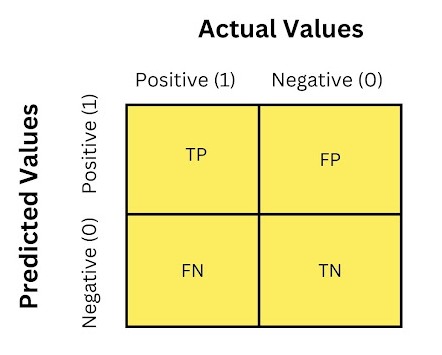

-> Bir görselde 20 tane yaka kartı olduğunu varsayalım. 18 tanesi yaka kartı diye bulunmuş olsun ve bunlardan 16 tanesi doğru.


Precision: 16/18 (Doğru bulunan yaka kartı sayısı/bulunan yaka kartı sayısı) -> (TP/TP+FP)

Recall: 16/20 (Doğru bulunan yaka kartı sayısı/gerçekte olan yaka kartı sayısı)  -> (TP/TP+FN)

Precision ve Recall değerleri 1'e ne kadar yakınsa o kadar ideal model

F1: 2 x (PxR)/(P+R) -> Precision ve Recall değerlerinin hormonik ortaması. Ne kadar yüksekse o kadar başarılı.

In [8]:
!ls /content/drive/MyDrive/data/id_cards_results/yolov12n/weights

best.pt  last.pt


In [9]:
from ultralytics import YOLO

test_image_path_two = "/content/drive/MyDrive/data/datasets/id_cards_dataset/test/id_card_image.png"

model_path = "/content/drive/MyDrive/data/id_cards_results/yolov12n/weights/best.pt"
model = YOLO(model_path)



image 1/1 /content/drive/MyDrive/data/datasets/id_cards_dataset/test/images/young-beautiful-business-woman-wearing-260nw-1477701170_jpg.rf.c1c7dc82036337b0a019c07517da7bd7.jpg: 640x640 1 ID card, 1 person, 14.0ms
Speed: 1.8ms preprocess, 14.0ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


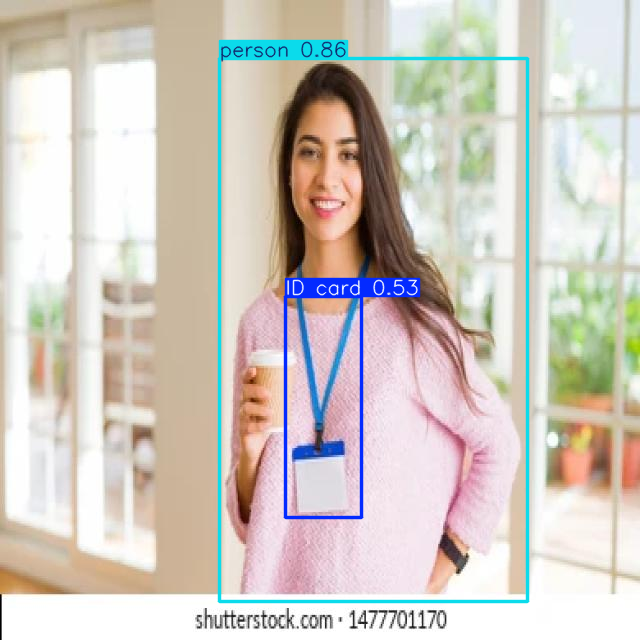

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([1., 0.], device='cuda:0')
conf: tensor([0.8587, 0.5319], device='cuda:0')
data: tensor([[2.1992e+02, 5.8380e+01, 5.2721e+02, 6.0173e+02, 8.5868e-01, 1.0000e+00],
        [2.8527e+02, 2.9679e+02, 3.6133e+02, 5.1700e+02, 5.3188e-01, 0.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (640, 640)
shape: torch.Size([2, 6])
xywh: tensor([[373.5677, 330.0533, 307.2905, 543.3459],
        [323.2992, 406.8975,  76.0643, 220.2073]], device='cuda:0')
xywhn: tensor([[0.5837, 0.5157, 0.4801, 0.8490],
        [0.5052, 0.6358, 0.1189, 0.3441]], device='cuda:0')
xyxy: tensor([[219.9225,  58.3804, 527.2130, 601.7263],
        [285.2670, 296.7938, 361.3313, 517.0011]], device='cuda:0')
xyxyn: tensor([[0.3436, 0.0912, 0.8238, 0.9402],
        [0.4457, 0.4637, 0.5646, 0.8078]], device='cuda:0')
2


In [10]:
test_image_path = "/content/drive/MyDrive/data/datasets/id_cards_dataset/test/images/young-beautiful-business-woman-wearing-260nw-1477701170_jpg.rf.c1c7dc82036337b0a019c07517da7bd7.jpg"

results = model(test_image_path)
results[0].show()

print(results[0].boxes)
print(len(results[0].boxes))

In [11]:
import os

folder_path = "/content/drive/MyDrive/data/datasets/id_cards_dataset/test/images/"

save_folder = "/content/drive/MyDrive/data/datasets/id_cards_dataset/results/"
os.makedirs(save_folder, exist_ok=True)


for image in os.listdir(folder_path):

    if not image.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    test_image_path = os.path.join(folder_path, image)

    results = model(test_image_path)

    # Tespit edilmiş görüntüyü kaydet
    save_path = os.path.join(save_folder, image)
    results[0].save(filename=save_path)

    print(f"\nImage: {image}")
    print(results[0].boxes)
    print("Detection count:", len(results[0].boxes))


image 1/1 /content/drive/MyDrive/data/datasets/id_cards_dataset/test/images/v99_png.rf.a6614ad04231b78744eeb49f8b4983aa.jpg: 640x640 3 ID cards, 5 persons, 19.0ms
Speed: 2.9ms preprocess, 19.0ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)

Image: v99_png.rf.a6614ad04231b78744eeb49f8b4983aa.jpg
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([1., 1., 1., 1., 0., 1., 0., 0.], device='cuda:0')
conf: tensor([0.8410, 0.5675, 0.3445, 0.3439, 0.3109, 0.2768, 0.2760, 0.2724], device='cuda:0')
data: tensor([[1.6025e+02, 2.4455e+01, 5.5200e+02, 6.3172e+02, 8.4098e-01, 1.0000e+00],
        [5.0762e+02, 1.0602e+02, 6.4000e+02, 6.3992e+02, 5.6750e-01, 1.0000e+00],
        [2.7919e-01, 1.6528e+02, 1.5171e+02, 6.4000e+02, 3.4452e-01, 1.0000e+00],
        [5.8365e+01, 1.4882e+02, 2.5625e+02, 6.3886e+02, 3.4395e-01, 1.0000e+00],
        [2.9152e+02, 2.6660e+02, 3.7743e+02, 4.9756e+02, 3.1090e-01, 0.0000e+00],
        [5.1968e+00, 1.5728e+02, 2.3249e+02, 6.400

In [12]:
import cv2
import os


name= "IMG_2644" #2643 - 2644
video_path = f"/content/drive/MyDrive/data/datasets/id_cards_dataset/test/videos/{name}.mov"

cap = cv2.VideoCapture(video_path)

output_path = f"/content/drive/MyDrive/data/datasets/id_cards_dataset/results/{name}_detected_3.mp4"

os.makedirs(os.path.dirname(output_path), exist_ok=True)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height)
)

frame_count = 0
total_detections = 0

while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    results = model(frame)

    detection_count = len(results[0].boxes)
    total_detections += detection_count

    print(f"Frame {frame_count}: {detection_count} detection")

    annotated_frame = results[0].plot()

    out.write(annotated_frame)

    frame_count += 1

cap.release()
out.release()

print("\nVideo kaydedildi:", output_path)
print("Toplam frame:", frame_count)
print("Toplam detection:", total_detections)


0: 640x384 1 person, 96.5ms
Speed: 10.3ms preprocess, 96.5ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 384)
Frame 0: 1 detection

0: 640x384 1 person, 49.3ms
Speed: 9.7ms preprocess, 49.3ms inference, 4.0ms postprocess per image at shape (1, 3, 640, 384)
Frame 1: 1 detection

0: 640x384 1 person, 49.0ms
Speed: 8.6ms preprocess, 49.0ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 384)
Frame 2: 1 detection

0: 640x384 1 person, 43.5ms
Speed: 8.1ms preprocess, 43.5ms inference, 4.8ms postprocess per image at shape (1, 3, 640, 384)
Frame 3: 1 detection

0: 640x384 1 person, 44.6ms
Speed: 7.2ms preprocess, 44.6ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 384)
Frame 4: 1 detection

0: 640x384 1 person, 63.3ms
Speed: 12.3ms preprocess, 63.3ms inference, 4.3ms postprocess per image at shape (1, 3, 640, 384)
Frame 5: 1 detection

0: 640x384 1 person, 53.6ms
Speed: 6.4ms preprocess, 53.6ms inference, 4.1ms postprocess per image at shape (1, 3, 

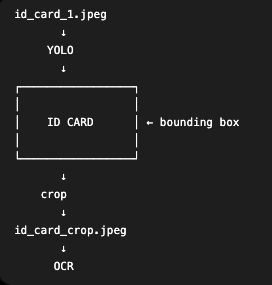

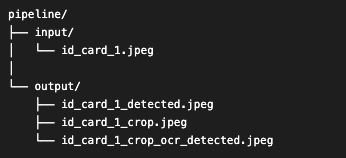


image 1/1 /content/drive/MyDrive/data/datasets/id_cards_dataset/pipeline/input/id_card_image.png: 640x608 2 ID cards, 1 person, 60.6ms
Speed: 2.5ms preprocess, 60.6ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 608)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([1., 0., 0.], device='cuda:0')
conf: tensor([0.9121, 0.4454, 0.3383], device='cuda:0')
data: tensor([[2.3191e+01, 0.0000e+00, 7.1700e+02, 7.6200e+02, 9.1205e-01, 1.0000e+00],
        [3.0536e+02, 3.4218e+02, 4.9974e+02, 7.4906e+02, 4.4543e-01, 0.0000e+00],
        [3.3718e+02, 4.0153e+02, 4.6378e+02, 7.5697e+02, 3.3829e-01, 0.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (762, 717)
shape: torch.Size([3, 6])
xywh: tensor([[370.0955, 381.0000, 693.8090, 762.0000],
        [402.5489, 545.6195, 194.3854, 406.8874],
        [400.4797, 579.2480, 126.5918, 355.4414]], device='cuda:0')
xywhn: tensor([[0.5162, 0.5000, 0.9677, 1.0000],
        [0.5614, 0.7160, 0.2711, 0.5340],
 

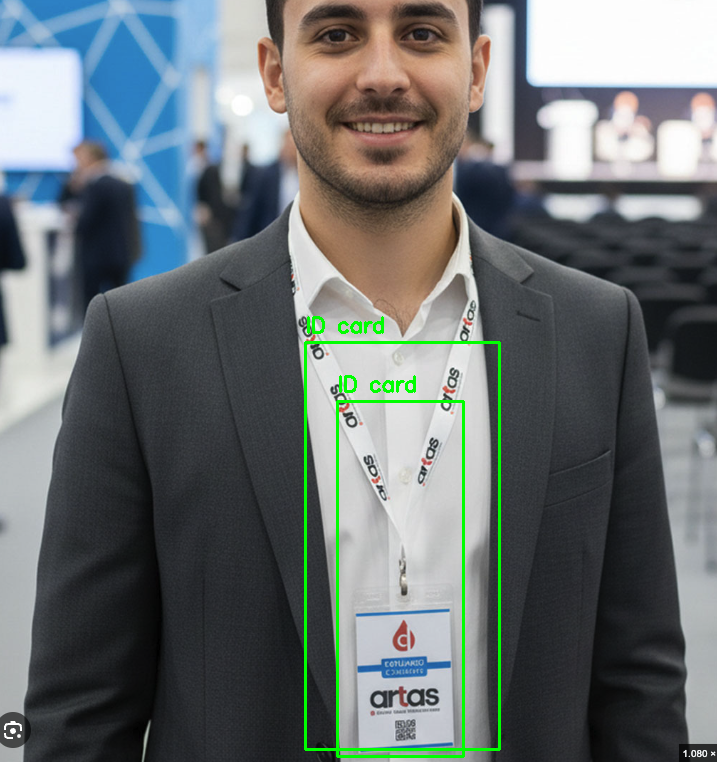

Cropped Area:


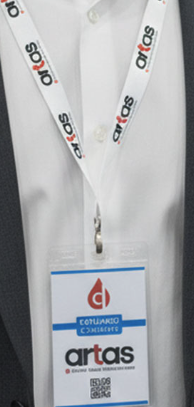


Kaydedilen dosyalar:
Detected: /content/drive/MyDrive/data/datasets/id_cards_dataset/pipeline/output/id_card_image_detected.png
Crop: /content/drive/MyDrive/data/datasets/id_cards_dataset/pipeline/output/id_card_image_crop.png


In [13]:
from ultralytics import YOLO
import cv2
import os
import shutil
from google.colab.patches import cv2_imshow

model_path = "/content/drive/MyDrive/data/id_cards_results/yolov12n/weights/best.pt"

source_image = "/content/drive/MyDrive/data/datasets/id_cards_dataset/test/id_card_image.png"

pipeline_path = "/content/drive/MyDrive/data/datasets/id_cards_dataset/pipeline"

input_folder = os.path.join(pipeline_path, "input")
output_folder = os.path.join(pipeline_path, "output")

os.makedirs(input_folder, exist_ok=True)
os.makedirs(output_folder, exist_ok=True)

# INPUT
filename = os.path.basename(source_image)

input_path = os.path.join(input_folder, filename)

# Orijinal resmi pipeline/input içine kopyala
shutil.copy2(source_image, input_path)

# MODEL
model = YOLO(model_path)

image = cv2.imread(input_path)

results = model(input_path)

print(results[0].boxes)
print("Detection count:", len(results[0].boxes))

# DETECTION
id_card_boxes = results[0].boxes[results[0].boxes.cls == 0]

if len(id_card_boxes) > 0:

    x1, y1, x2, y2 = id_card_boxes.xyxy[0].cpu().numpy().astype(int)

    print("Bounding box:")
    print(x1, y1, x2, y2)

    # Sadece ID card crop
    crop = image[y1:y2, x1:x2]

    # Person + ID card detection
    # print("YOLO Detection: Person + ID card ")
    # detected_image = results[0].plot()
    # cv2_imshow(detected_image)

    # Sadece ID card detection'larını çiz
    detected_image = image.copy()


    for box in id_card_boxes.xyxy.cpu().numpy().astype(int):
        bx1, by1, bx2, by2 = box
        cv2.rectangle(detected_image, (bx1, by1), (bx2, by2), (0, 255, 0), 2)
        cv2.putText(detected_image, "ID card", (bx1, max(by1 - 10, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    # GÖRSELLEŞTİR
    print("YOLO Detection:")
    cv2_imshow(detected_image)

    print("Cropped Area:")
    cv2_imshow(crop)

    # OUTPUT
    name, ext = os.path.splitext(filename)

    detected_path = os.path.join(output_folder, f"{name}_detected{ext}")
    crop_path = os.path.join(output_folder, f"{name}_crop{ext}")

    # Detection görüntüsünü kaydet
    cv2.imwrite(detected_path, detected_image)

    # Crop görüntüsünü kaydet
    cv2.imwrite(crop_path, crop)

    print("\nKaydedilen dosyalar:")
    print("Detected:", detected_path)
    print("Crop:", crop_path)

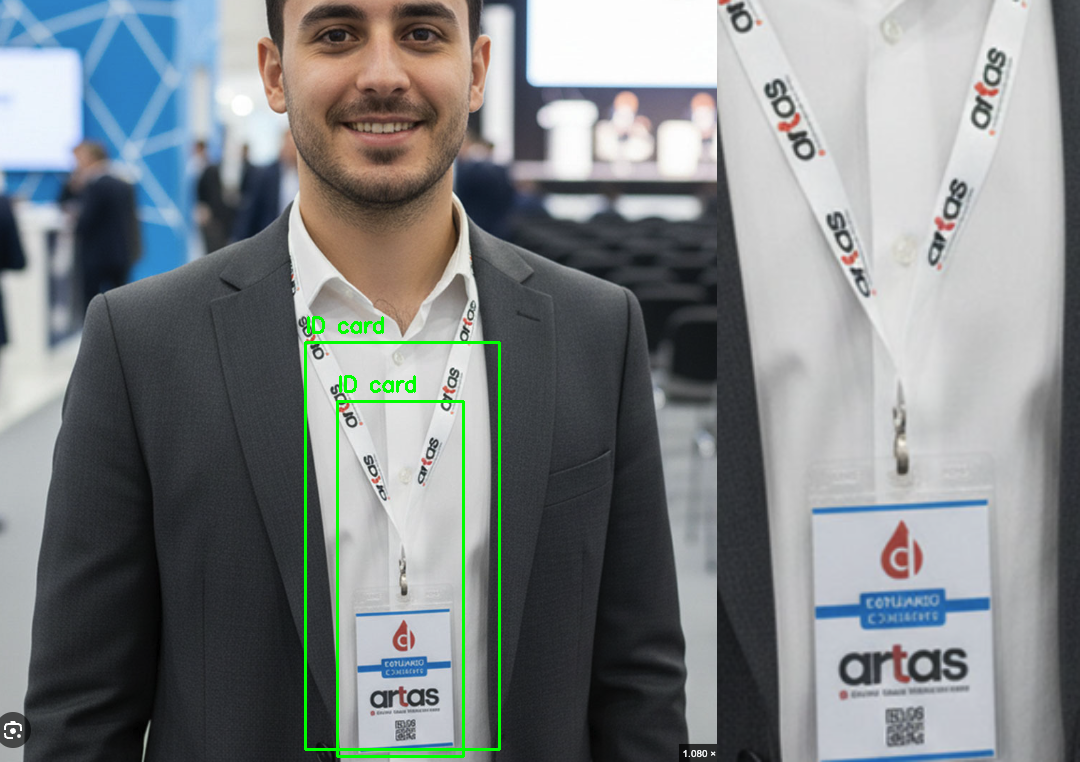

In [14]:
from google.colab.patches import cv2_imshow

# Kaydedilen görüntüleri oku
detected_image = cv2.imread(detected_path)
crop = cv2.imread(crop_path)

# Yan yana göstermek için aynı yüksekliğe getir
height = min(detected_image.shape[0], 800)

detected_width = int(detected_image.shape[1] * height / detected_image.shape[0])
crop_width = int(crop.shape[1] * height / crop.shape[0])

detected_resized = cv2.resize(detected_image, (detected_width, height))
crop_resized = cv2.resize(crop, (crop_width, height))

combined = cv2.hconcat([detected_resized, crop_resized])

cv2_imshow(combined)

EasyOCR bize yalnızca metni değil, metnin görüntü üzerindeki konumunu da 4 noktalı bir bounding box olarak döndürüyor. Bu dört nokta sayesinde metnin nerede olduğunu biliyoruz.


bbox → text'in konumu

text → OCR'ın okuduğu yazı

confidence → OCR'ın güven skoru



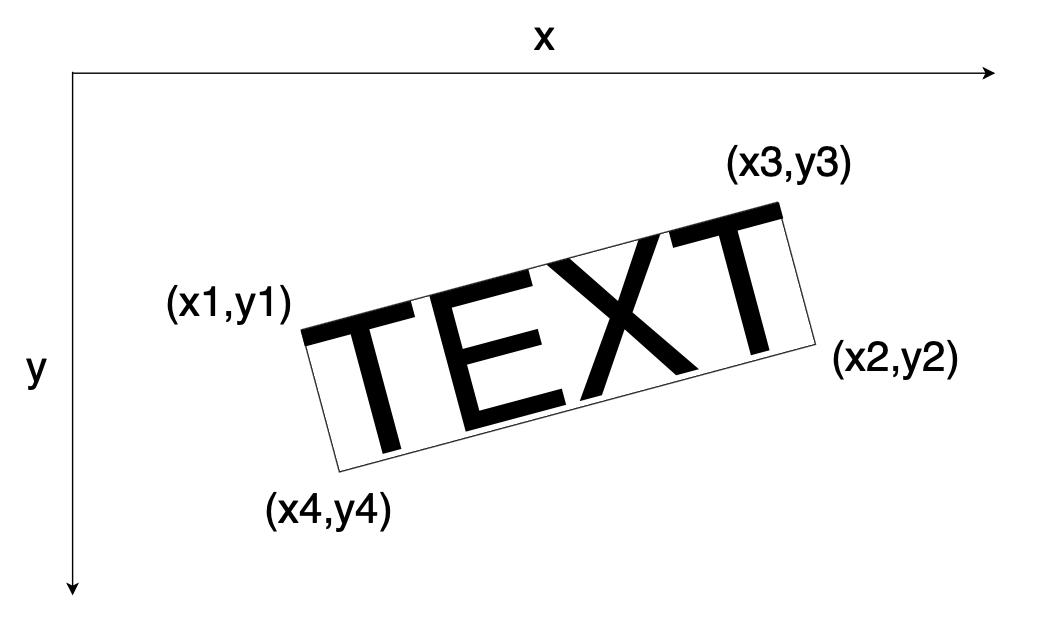




In [15]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 32.0 MB/s eta 0:00:00


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteText: 8 | Confidence: 0.49
Text: [onarto | Confidence: 0.07
Text: artas | Confidence: 1.00
Text: ğ | Confidence: 0.46
Text: 8 | Confidence: 0.85
Text: 8 | Confidence: 0.87
Text: Go7 | Confidence: 0.00


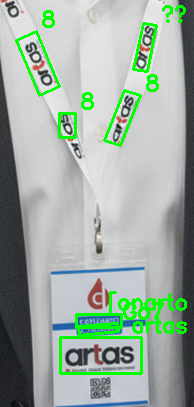


OCR sonucu kaydedildi: /content/drive/MyDrive/data/datasets/id_cards_dataset/pipeline/output/id_card_image_crop_ocr_detected.png


In [16]:
import easyocr
import cv2
import os
import numpy as np
from google.colab.patches import cv2_imshow

# Crop görüntüsünü oku
# crop_path = "/content/drive/MyDrive/data/datasets/id_cards_dataset/test/id_card_2.jpeg"
crop_path_2 = "/content/drive/MyDrive/data/datasets/id_cards_dataset/test/baskili-yaka-karti.png"

crop = cv2.imread(crop_path)

# OCR modelini yükle
reader = easyocr.Reader(['tr', 'en'], gpu=True)

# OCR yap
results = reader.readtext(crop)

# OCR sonuçlarını görüntü üzerine yaz
ocr_image = crop.copy()

for bbox, text, confidence in results:
    print(f"Text: {text} | Confidence: {confidence:.2f}")

    points = np.array([(int(x), int(y)) for x, y in bbox], dtype=np.int32)
    cv2.polylines(ocr_image, [points], True, (0, 255, 0), 2)

    points[0]  # sol üst
    points[1]  # sağ üst
    points[2]  # sağ alt
    points[3]  # sol alt

    x, y = points[1]
    text_size = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)[0]
    text_x = min(x + 5, ocr_image.shape[1] - text_size[0] - 5)
    text_y = max(y - 5, text_size[1] + 5)

    cv2.putText(ocr_image, text, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

# OCR sonucunu kaydet
name, ext = os.path.splitext(os.path.basename(crop_path))
ocr_path = os.path.join(output_folder, f"{name}_ocr_detected{ext}")
cv2.imwrite(ocr_path, ocr_image)

# OCR sonucunu göster
cv2_imshow(ocr_image)

print("\nOCR sonucu kaydedildi:", ocr_path)

Text: JANETTE DoE | Confidence: 0.54
Text: CSR/Sales | Confidence: 0.92
Text: Employee signature: | Confidence: 0.45
Text: JANETTE DOE | Confidence: 0.78
Text: CSRISales | Confidence: 0.92
Text: Qune | Confidence: 0.09
Text: EE No 360 030 | Confidence: 0.64
Text: Emoloyce iD; 024578 | Confidence: 0.33
Text: 5SS: 02-22257568-5 | Confidence: 0.44
Text: TIN: 239-119-329 | Confidence: 0.98
Text: Philhcalth: 03-048448448-0 | Confidence: 0.70
Text: HOMF: 1245-3259-6758 | Confidence: 0.85
Text: EMPLOYEEEMERGENCYCONTACT | Confidence: 0.70
Text: Contact Name: John Doc | Confidence: 0.85
Text: Contact No 020-334-444 | Confidence: 0.91
Text: SUPPORT | Confidence: 0.86
Text: NINJA | Confidence: 0.95
Text: Hprir | Confidence: 0.01


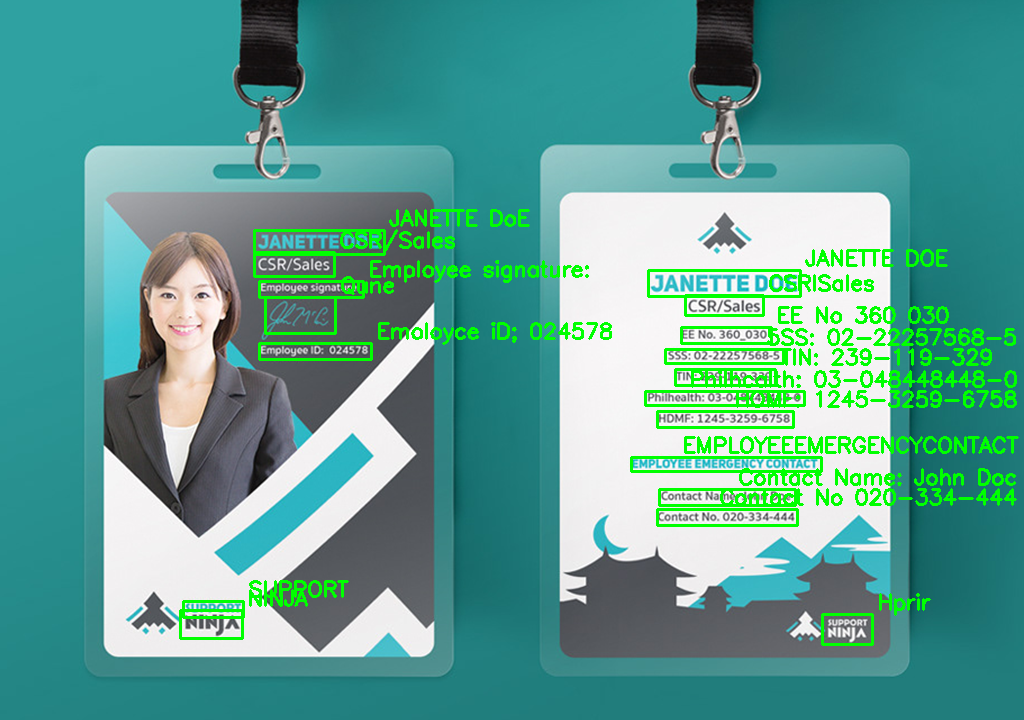


OCR sonucu kaydedildi: /content/drive/MyDrive/data/datasets/id_cards_dataset/pipeline/output/id_card_image_crop_ocr_detected2.png


In [17]:
import easyocr
import cv2
import os
import numpy as np
from google.colab.patches import cv2_imshow

# Crop görüntüsünü oku
# crop_path = "/content/drive/MyDrive/data/datasets/id_cards_dataset/test/id_card_2.jpeg"
crop_path_2 = "/content/drive/MyDrive/data/datasets/id_cards_dataset/test/baskili-yaka-karti.png"

crop = cv2.imread(crop_path_2)

# OCR modelini yükle
reader = easyocr.Reader(['tr', 'en'], gpu=True)

# OCR yap
results = reader.readtext(crop)

# OCR sonuçlarını görüntü üzerine yaz
ocr_image = crop.copy()

for bbox, text, confidence in results:
    print(f"Text: {text} | Confidence: {confidence:.2f}")

    points = np.array([(int(x), int(y)) for x, y in bbox], dtype=np.int32)
    cv2.polylines(ocr_image, [points], True, (0, 255, 0), 2)

    points[0]  # sol üst
    points[1]  # sağ üst
    points[2]  # sağ alt
    points[3]  # sol alt

    x, y = points[1]
    text_size = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)[0]
    text_x = min(x + 5, ocr_image.shape[1] - text_size[0] - 5)
    text_y = max(y - 5, text_size[1] + 5)

    cv2.putText(ocr_image, text, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

# OCR sonucunu kaydet
name, ext = os.path.splitext(os.path.basename(crop_path))
ocr_path = os.path.join(output_folder, f"{name}_ocr_detected2{ext}")
cv2.imwrite(ocr_path, ocr_image)

# OCR sonucunu göster
cv2_imshow(ocr_image)

print("\nOCR sonucu kaydedildi:", ocr_path)

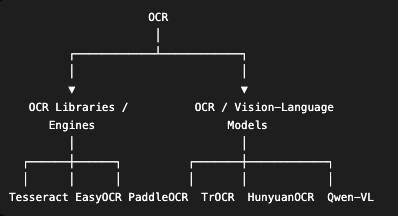

In [1]:
!pip install paddleocr paddlepaddle

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('UVDoc', None, None)
Using official model (UVDoc), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/UVDoc`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

...

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Creating model: ('PP-OCRv6_medium_rec', None, None)
Using official model (PP-OCRv6_medium_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_rec`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Text: JANETTEDOE | Confidence: 1.00
Text: CSR/Sales | Confidence: 1.00
Text: Employee signature: | Confidence: 1.00
Text: JANETTEDOE | Confidence: 1.00
Text: JL7ML | Confidence: 0.66
Text: CSR/Sales | Confidence: 1.00
Text: EE No. 360_030 | Confidence: 0.97
Text: Employee ID: 024578 | Confidence: 1.00
Text: SSS:02-22257568-5 | Confidence: 1.00
Text: TIN:239-119-329 | Confidence: 1.00
Text: Philhealth: 03-048448448-0 | Confidence: 0.99
Text: HDMF:1245-3259-6758 | Confidence: 1.00
Text: EMPLOYEEEMERGENCYCONTACT | Confidence: 1.00
Text: Contact Name: John Doe | Confidence: 1.00
Text: Contact No. 020-334-444 | Confidence: 0.98
Text: SUPPORT | Confidence: 1.00
Text: NINJA | Confidence: 1.00
Text: NINJA | Confidence: 1.00
Text: SUPPORT | Confidence: 1.00


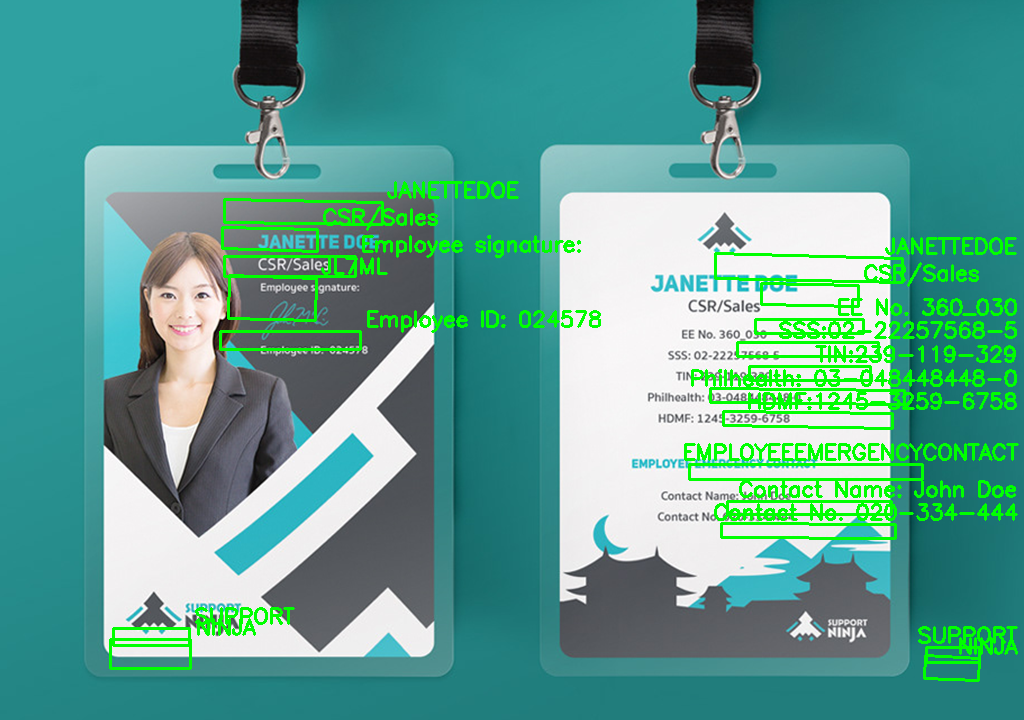


OCR sonucu kaydedildi: /content/drive/MyDrive/data/datasets/id_cards_dataset/results/baskili-yaka-karti_ocr_detected.png


In [2]:
import os

os.environ["FLAGS_enable_pir_api"] = "0"

from paddleocr import PaddleOCR
import cv2
import os
import numpy as np
from google.colab.patches import cv2_imshow

# Crop görüntüsünü oku
crop_path = "/content/drive/MyDrive/data/datasets/id_cards_dataset/test/baskili-yaka-karti.png"
output_folder = "/content/drive/MyDrive/data/datasets/id_cards_dataset/results"
crop = cv2.imread(crop_path)

# OCR modelini yükle
ocr = PaddleOCR(lang="en", enable_mkldnn=False)

# OCR yap
results = ocr.predict(crop)

# OCR sonuçlarını görüntü üzerine yaz
ocr_image = crop.copy()

for result in results:

    data = result.json

    for bbox, text, confidence in zip(data["res"]["rec_polys"], data["res"]["rec_texts"], data["res"]["rec_scores"]):

        print(f"Text: {text} | Confidence: {confidence:.2f}")

        points = np.array(bbox, dtype=np.int32)

        cv2.polylines(ocr_image, [points], True, (0, 255, 0), 2)

        x, y = points[1]

        text_size = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)[0]
        text_x = min(x + 5, ocr_image.shape[1] - text_size[0] - 5)
        text_y = max(y - 5, text_size[1] + 5)

        cv2.putText(ocr_image, text, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

# OCR sonucunu kaydet
name, ext = os.path.splitext(os.path.basename(crop_path))
os.makedirs(output_folder, exist_ok=True)
ocr_path = os.path.join(output_folder, f"{name}_ocr_detected{ext}")
cv2.imwrite(ocr_path, ocr_image)

# OCR sonucunu göster
cv2_imshow(ocr_image)

print("\nOCR sonucu kaydedildi:", ocr_path)

In [16]:
!pip install -U transformers accelerate pillow

In [3]:
import torch

print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU yok!")

CUDA: True
GPU: Tesla T4


In [4]:
import torch
from PIL import Image
from transformers import AutoProcessor, HunYuanVLForConditionalGeneration

model_id = "tencent/HunyuanOCR"

processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True, use_fast=False)

model = HunYuanVLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="cpu", #"cpu" "auto"
    trust_remote_code=True
).eval()

preprocessor_config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/994 [00:00<?, ?B/s]

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


config.json:   0%|          | 0.00/4.77k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/167k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/836 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.24GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/714 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/139 [00:00<?, ?B/s]

In [5]:
crop_path = "/content/drive/MyDrive/data/datasets/id_cards_dataset/test/baskili-yaka-karti.png"
# crop_path = "/content/drive/MyDrive/data/datasets/id_cards_dataset/test/id_card_2.jpeg"
image = Image.open(crop_path).convert("RGB")

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "Read every visible text in the image and return the recognized texts as a JSON array. Use one object per text region with the key 'text'. Return only the JSON array."}
        ]
    }
]

inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_tensors="pt",
    return_dict=True
).to(model.device)

with torch.inference_mode():
    output = model.generate(
        **inputs,
        max_new_tokens=512
    )

import json

response = processor.batch_decode(output, skip_special_tokens=True)[0]

try:
    json_start = response.find("[")

    if json_start == -1:
        print("JSON bulunamadı.")
        print("Model çıktısı:")
        print(response)
    else:
        decoder = json.JSONDecoder()
        ocr_data, end = decoder.raw_decode(response[json_start:])

        print(json.dumps(ocr_data, ensure_ascii=False, indent=2))

except json.JSONDecodeError:
    print("JSON formatında sonuç alınamadı.")
    print("Model çıktısı:")
    print(response)

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[
  {
    "box": [
      251,
      324,
      373,
      348
    ],
    "text": "JANETTE DOE"
  },
  {
    "box": [
      251,
      357,
      324,
      378
    ],
    "text": "CSR/Sales"
  },
  {
    "box": [
      635,
      380,
      782,
      407
    ],
    "text": "JANETTE DOE"
  },
  {
    "box": [
      253,
      392,
      353,
      410
    ],
    "text": "Employee signature:"
  },
  {
    "box": [
      671,
      415,
      745,
      435
    ],
    "text": "CSR/Sales"
  },
  {
    "box": [
      254,
      417,
      324,
      472
    ],
    "text": "glme"
  },
  {
    "box": [
      665,
      457,
      751,
      474
    ],
    "text": "EE No. 360_030"
  },
  {
    "box": [
      253,
      479,
      361,
      496
    ],
    "text": "Employee ID: 024578"
  },
  {
    "box": [
      651,
      486,
      764,
      503
    ],
    "text": "SSS: 02-22257568-5"
  },
  {
    "box": [
      659,
      516,
      756,
      532
    ],
    "text": "TIN: 239-119-329"
  }

JSON başarıyla alındı.


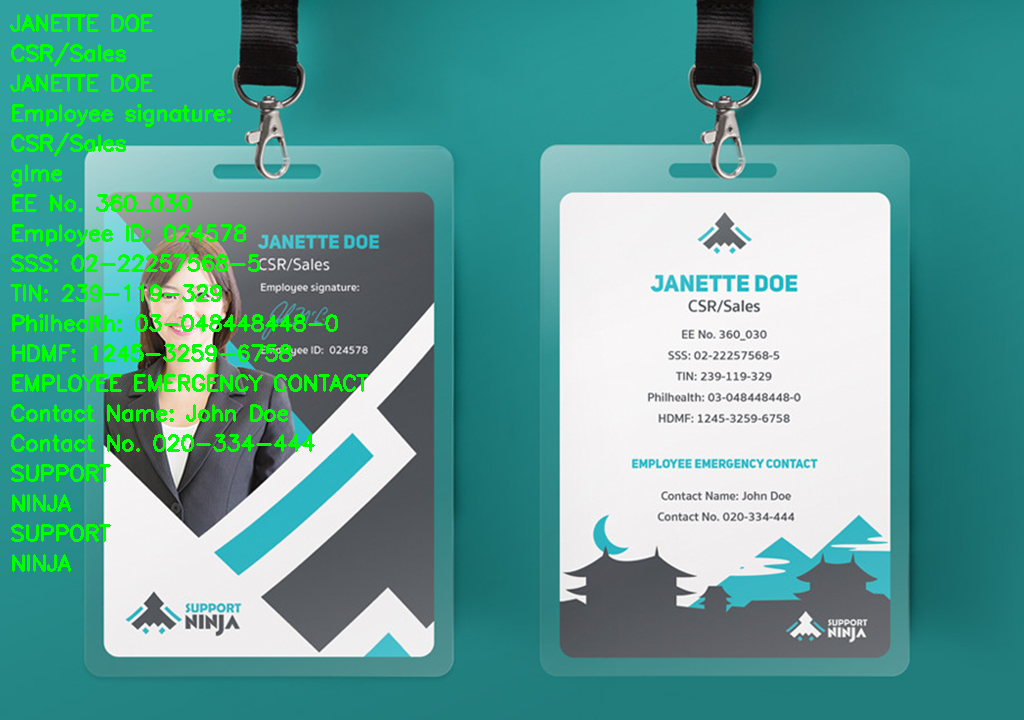

In [6]:
import json
import cv2
from google.colab.patches import cv2_imshow

ocr_image = cv2.imread(crop_path)

font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.7
thickness = 2
y = 30

try:
    json_start = response.find("[")

    if json_start == -1:
        raise ValueError("JSON bulunamadı")

    decoder = json.JSONDecoder()
    ocr_data, end = decoder.raw_decode(response[json_start:])

    print("JSON başarıyla alındı.")

    for item in ocr_data:
        text_value = item["text"]

        cv2.putText(ocr_image, text_value, (10, y), font, font_scale, (0, 255, 0), thickness)

        y += 30

except (json.JSONDecodeError, ValueError, KeyError, TypeError):
    print("JSON formatında sonuç alınamadı.")
    print("\nModel çıktısı:\n")
    print(response)

    cv2.putText(ocr_image, "JSON formatinda sonuc alinamadi.", (10, y), font, 0.7, (0, 0, 255), 2)

cv2_imshow(ocr_image)